# Question 10: Boston Dataset - KNN Smoother with 22-Fold Cross-Validation
## Advanced Regression - Problem Set 3

This notebook applies KNN smoothers to the Boston dataset using 22-fold cross-validation to find the optimal k (number of nearest neighbors).
The response variable is **medv** (Median home value in $1000s) and the predictor is **lstat** (% lower status population).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Step 1: Load the Boston Dataset from CSV

In [3]:
# Load Boston dataset from CSV file
boston_df = pd.read_csv('Boston.csv')

# Extract predictor (lstat) and response (medv)
# lstat: % lower status population
# medv: Median home value in $1000s
X_full = boston_df['lstat'].values.reshape(-1, 1)  # KNN requires 2D array
Y_full = boston_df['medv'].values

print(f"Dataset loaded successfully!")
print(f"Dataset shape: {len(X_full)} observations")
print(f"\nColumns in dataset: {boston_df.columns.tolist()}")
print(f"\nX (lstat - % lower status) range: [{X_full.min():.2f}, {X_full.max():.2f}]")
print(f"Y (medv - Median home value in $1000s) range: [{Y_full.min():.2f}, {Y_full.max():.2f}]")
print(f"\nFirst 10 observations:")
print(boston_df[['lstat', 'medv']].head(10))
print(f"\nDataset statistics:")
print(boston_df[['lstat', 'medv']].describe())

Dataset loaded successfully!
Dataset shape: 506 observations

Columns in dataset: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv']

X (lstat - % lower status) range: [1.73, 37.97]
Y (medv - Median home value in $1000s) range: [5.00, 50.00]

First 10 observations:
   lstat  medv
0   4.98  24.0
1   9.14  21.6
2   4.03  34.7
3   2.94  33.4
4   5.33  36.2
5   5.21  28.7
6  12.43  22.9
7  19.15  27.1
8  29.93  16.5
9  17.10  18.9

Dataset statistics:
            lstat        medv
count  506.000000  506.000000
mean    12.653063   22.532806
std      7.141062    9.197104
min      1.730000    5.000000
25%      6.950000   17.025000
50%     11.360000   21.200000
75%     16.955000   25.000000
max     37.970000   50.000000


## Step 2: Create 22 Strata of Equal Size

In [4]:
# Divide observations into 22 strata of equal size
n_strata = 22
n_samples = len(X_full)
stratum_size = n_samples // n_strata

print(f"Total observations: {n_samples}")
print(f"Number of strata: {n_strata}")
print(f"Stratum size: {stratum_size} (with {n_samples % n_strata} extra samples)")

# Create stratified indices by sorting based on X values
# This ensures each stratum has observations from different ranges of lstat
sorted_indices = np.argsort(X_full.ravel())
X_sorted = X_full[sorted_indices]
Y_sorted = Y_full[sorted_indices]
indices_sorted = sorted_indices.copy()

# Create strata
strata = []
for i in range(n_strata):
    start_idx = i * stratum_size
    end_idx = start_idx + stratum_size if i < n_strata - 1 else n_samples
    strata.append(indices_sorted[start_idx:end_idx])

print(f"\nStratum sizes: {[len(s) for s in strata]}")
print(f"\nStratum ranges (lstat values):")
for i, stratum in enumerate(strata[:5]):  # Show first 5 strata
    lstat_values = X_full[stratum]
    print(f"  Stratum {i+1}: lstat range [{lstat_values.min():.2f}, {lstat_values.max():.2f}]")
print(f"  ...")

Total observations: 506
Number of strata: 22
Stratum size: 23 (with 0 extra samples)

Stratum sizes: [23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23]

Stratum ranges (lstat values):
  Stratum 1: lstat range [1.73, 3.56]
  Stratum 2: lstat range [3.57, 4.56]
  Stratum 3: lstat range [4.59, 5.21]
  Stratum 4: lstat range [5.25, 5.98]
  Stratum 5: lstat range [5.98, 6.62]
  ...


## Step 3: Define KNN Smoother and Evaluation Functions

In [5]:
def knn_smoother(X_train, Y_train, X_test, k):
    """
    Apply KNN smoother algorithm.
    
    Algorithm:
    1. For each test point, find the k nearest neighbors in the training set
    2. Predict as the average of the k nearest neighbors' response values
    
    Parameters:
    -----------
    X_train : array-like of shape (n_train, 1), predictor values for training
    Y_train : array-like of shape (n_train,), response values for training
    X_test : array-like of shape (n_test, 1), predictor values for testing
    k : int, number of nearest neighbors
    
    Returns:
    --------
    Y_pred : array-like of shape (n_test,), predicted values for X_test
    """
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, Y_train)
    Y_pred = knn.predict(X_test)
    return Y_pred

def compute_mse(Y_actual, Y_pred):
    """
    Compute Mean Squared Error.
    """
    return mean_squared_error(Y_actual, Y_pred)

print("KNN smoother functions defined successfully!")

KNN smoother functions defined successfully!


## Step 4: 22-Fold Stratified Cross-Validation

In [6]:
# Range of k values to test (number of nearest neighbors)
k_values = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 23, 25]

# Store validation errors for each k
validation_errors = {k: [] for k in k_values}

# Perform 22-fold cross-validation
# At the i-th fold, the i-th stratum is the test set
# All other strata form the training set

print("Performing 22-fold stratified cross-validation...\n")
print(f"Testing k values: {k_values}")
print("\nProgress:")

for fold, test_stratum_idx in enumerate(range(n_strata)):
    # Test set: i-th stratum
    test_indices = strata[test_stratum_idx]
    X_test = X_full[test_indices]
    Y_test = Y_full[test_indices]
    
    # Training set: all other strata (21 strata)
    train_indices = np.concatenate([strata[i] for i in range(n_strata) if i != test_stratum_idx])
    X_train = X_full[train_indices]
    Y_train = Y_full[train_indices]
    
    if (fold + 1) % 5 == 0 or fold == 0:
        print(f"  Fold {fold + 1:2d}/{n_strata}: Train size = {len(X_train):3d}, Test size = {len(X_test):2d}")
    
    # Test different values of k
    for k in k_values:
        try:
            Y_pred = knn_smoother(X_train, Y_train, X_test, k)
            mse = compute_mse(Y_test, Y_pred)
            validation_errors[k].append(mse)
        except Exception as e:
            print(f"Error with k={k} in fold {fold+1}: {e}")

print(f"\nCross-validation completed!")

Performing 22-fold stratified cross-validation...

Testing k values: [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 23, 25]

Progress:
  Fold  1/22: Train size = 483, Test size = 23
  Fold  5/22: Train size = 483, Test size = 23
  Fold 10/22: Train size = 483, Test size = 23
  Fold 15/22: Train size = 483, Test size = 23
  Fold 20/22: Train size = 483, Test size = 23

Cross-validation completed!


## Step 5: Find the Best Model

In [7]:
# Calculate average validation error for each k
avg_validation_errors = {k: np.mean(validation_errors[k]) for k in k_values}
std_validation_errors = {k: np.std(validation_errors[k]) for k in k_values}
min_validation_errors = {k: np.min(validation_errors[k]) for k in k_values}
max_validation_errors = {k: np.max(validation_errors[k]) for k in k_values}

# Find best k
best_k = min(avg_validation_errors, key=avg_validation_errors.get)
best_error = avg_validation_errors[best_k]

# Create summary table
summary_df = pd.DataFrame({
    'k': k_values,
    'Avg MSE': [f"{avg_validation_errors[k]:.4f}" for k in k_values],
    'Std Dev': [f"{std_validation_errors[k]:.4f}" for k in k_values],
    'Min MSE': [f"{min_validation_errors[k]:.4f}" for k in k_values],
    'Max MSE': [f"{max_validation_errors[k]:.4f}" for k in k_values]
})

print("\n" + "="*90)
print("22-FOLD CROSS-VALIDATION RESULTS FOR KNN SMOOTHER")
print("="*90)
print(summary_df.to_string(index=False))
print("="*90)
print(f"\n*** BEST MODEL: k = {best_k} ***")
print(f"    Average Validation MSE: {best_error:.4f}")
print(f"    Std Dev: {std_validation_errors[best_k]:.4f}")
print("="*90)


22-FOLD CROSS-VALIDATION RESULTS FOR KNN SMOOTHER
 k Avg MSE Std Dev Min MSE  Max MSE
 1 36.1323 29.2378  7.1191 108.6848
 2 34.9567 26.4774  8.5465 111.6804
 3 32.1527 23.2362  7.8471  73.8813
 4 33.1504 25.4529  7.0243  90.6421
 5 31.8585 22.5255  5.4697  89.0214
 6 30.7916 20.8006  5.1371  73.3114
 8 29.2719 19.7398  5.7797  63.4345
10 28.6602 19.1860  7.4883  61.2261
12 28.3610 19.4760  7.7763  61.4766
15 27.3351 19.4863  6.6643  61.3228
20 27.5398 19.6738  5.7478  63.4110
23 27.8648 20.5343  5.4235  72.4895
25 27.8751 20.5782  5.7054  72.0111

*** BEST MODEL: k = 15 ***
    Average Validation MSE: 27.3351
    Std Dev: 19.4863


## Step 6: Visualize Cross-Validation Results

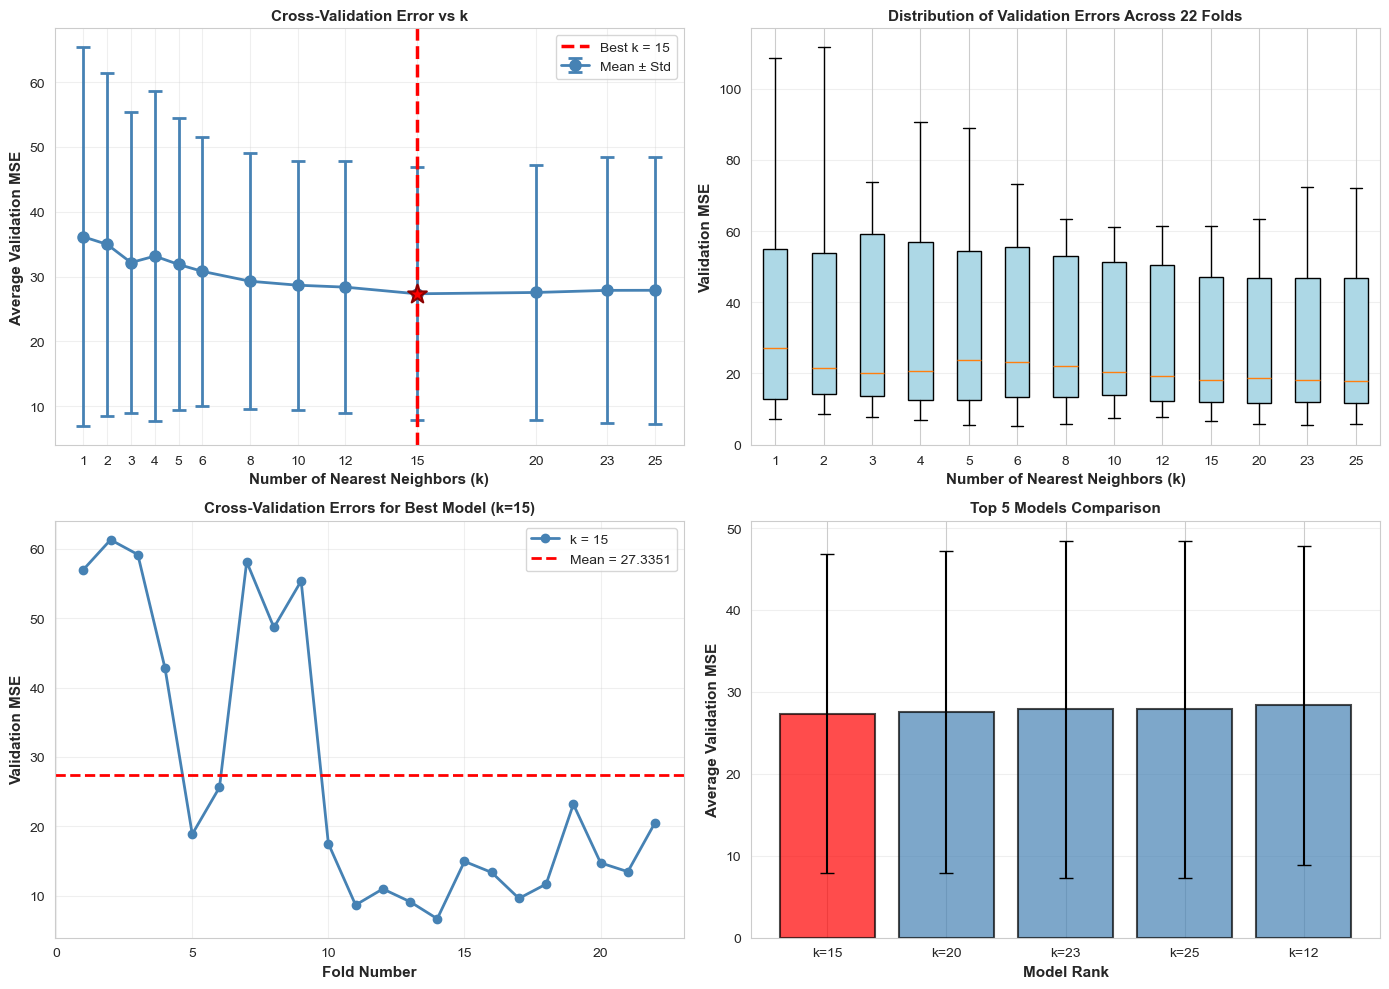

Visualization complete!


In [8]:
# Create comprehensive visualization of validation results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Average validation error vs k with error bars
k_list = list(avg_validation_errors.keys())
errors = list(avg_validation_errors.values())
stds = list(std_validation_errors.values())

axes[0, 0].errorbar(k_list, errors, yerr=stds, marker='o', linestyle='-', linewidth=2, 
                  markersize=8, capsize=5, capthick=2, color='steelblue', label='Mean ± Std')
axes[0, 0].axvline(x=best_k, color='red', linestyle='--', linewidth=2.5, label=f'Best k = {best_k}')
axes[0, 0].scatter([best_k], [best_error], color='red', s=200, marker='*', zorder=5, edgecolors='darkred', linewidth=1.5)
axes[0, 0].set_xlabel('Number of Nearest Neighbors (k)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Average Validation MSE', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Cross-Validation Error vs k', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=10, loc='best')
axes[0, 0].set_xticks(k_list)

# Plot 2: Distribution of errors across folds (box plot)
bp = axes[0, 1].boxplot([validation_errors[k] for k in k_list], labels=k_list, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[0, 1].set_xlabel('Number of Nearest Neighbors (k)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Validation MSE', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Distribution of Validation Errors Across 22 Folds', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: All individual fold errors for best k
axes[1, 0].plot(range(1, n_strata + 1), validation_errors[best_k], marker='o', linestyle='-', 
                color='steelblue', linewidth=2, markersize=6, label=f'k = {best_k}')
axes[1, 0].axhline(y=best_error, color='red', linestyle='--', linewidth=2, label=f'Mean = {best_error:.4f}')
axes[1, 0].set_xlabel('Fold Number', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Validation MSE', fontsize=11, fontweight='bold')
axes[1, 0].set_title(f'Cross-Validation Errors for Best Model (k={best_k})', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=10)

# Plot 4: Comparison of top models
sorted_models = sorted(avg_validation_errors.items(), key=lambda x: x[1])
top_k_vals = [k for k, _ in sorted_models[:5]]
top_errors = [avg_validation_errors[k] for k in top_k_vals]
top_stds = [std_validation_errors[k] for k in top_k_vals]
colors = ['red' if k == best_k else 'steelblue' for k in top_k_vals]

bars = axes[1, 1].bar(range(len(top_k_vals)), top_errors, yerr=top_stds, capsize=5, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].set_xlabel('Model Rank', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Average Validation MSE', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Top 5 Models Comparison', fontsize=11, fontweight='bold')
axes[1, 1].set_xticks(range(len(top_k_vals)))
axes[1, 1].set_xticklabels([f'k={k}' for k in top_k_vals])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Visualization complete!")

## Step 7: Fit the Best Model and Visualize

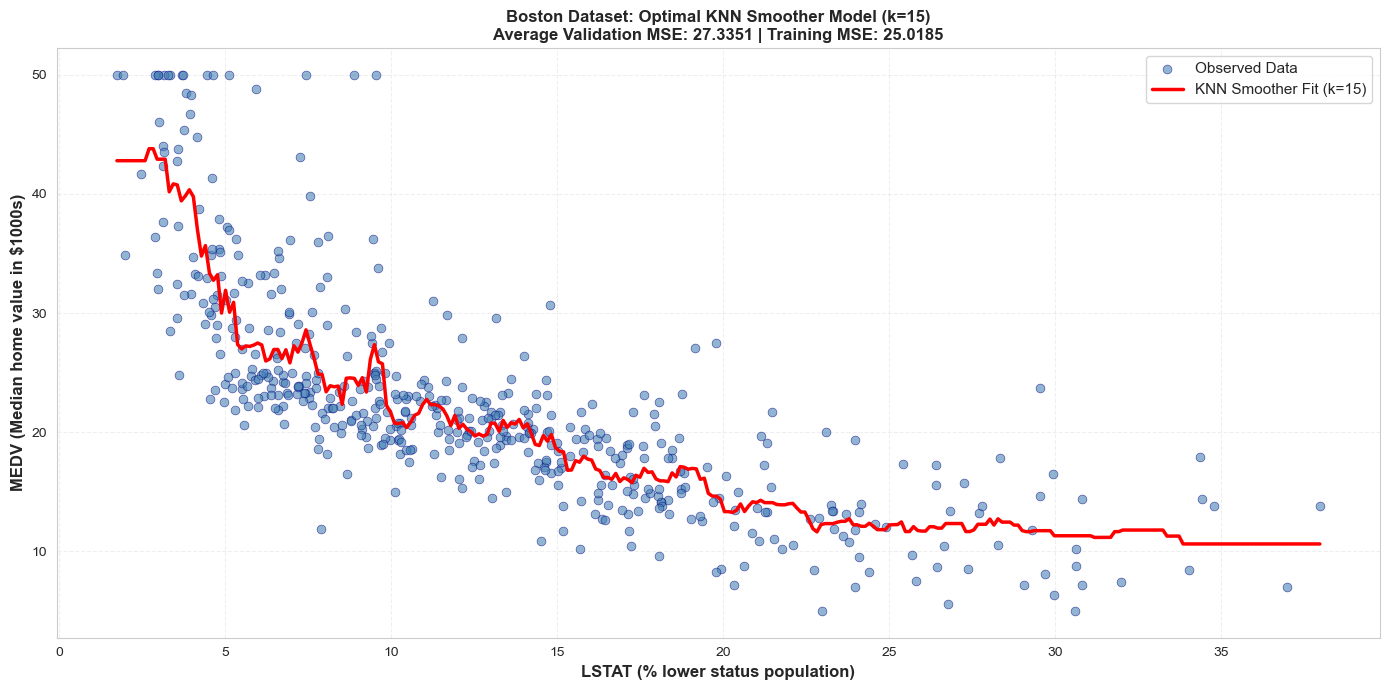


Best Model Fitted Successfully!
Number of nearest neighbors (k): 15
Training MSE: 25.0185
Average Validation MSE: 27.3351


In [9]:
# Fit the best model on the entire dataset
Y_pred_best = knn_smoother(X_full, Y_full, X_full, best_k)

# Create a fine grid for smooth visualization
X_grid = np.linspace(X_full.min(), X_full.max(), 300).reshape(-1, 1)
Y_grid_pred = knn_smoother(X_full, Y_full, X_grid, best_k)

# Calculate training MSE for best model
train_mse_best = compute_mse(Y_full, Y_pred_best)

# Plot the fitted model
fig, ax = plt.subplots(figsize=(14, 7))

# Scatter plot of actual data
ax.scatter(X_full, Y_full, alpha=0.6, s=40, color='steelblue', edgecolors='navy', linewidth=0.5, label='Observed Data')

# Plot KNN smoother fit
ax.plot(X_grid, Y_grid_pred, color='red', linewidth=2.5, label=f'KNN Smoother Fit (k={best_k})', zorder=4)

ax.set_xlabel('LSTAT (% lower status population)', fontsize=12, fontweight='bold')
ax.set_ylabel('MEDV (Median home value in $1000s)', fontsize=12, fontweight='bold')
ax.set_title(f'Boston Dataset: Optimal KNN Smoother Model (k={best_k})\n'
            f'Average Validation MSE: {best_error:.4f} | Training MSE: {train_mse_best:.4f}',
            fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\nBest Model Fitted Successfully!")
print(f"Number of nearest neighbors (k): {best_k}")
print(f"Training MSE: {train_mse_best:.4f}")
print(f"Average Validation MSE: {best_error:.4f}")

## Step 8: Detailed Summary and Conclusions

In [10]:
print("\n" + "="*80)
print("SUMMARY AND CONCLUSIONS")
print("="*80)

print(f"\n📊 DATASET INFORMATION:")
print(f"-" * 80)
print(f"Dataset: Boston Housing Dataset")
print(f"Total observations: {len(X_full)}")
print(f"Response Variable (Y): MEDV (Median home value in $1000s)")
print(f"  Range: [{Y_full.min():.2f}, {Y_full.max():.2f}]")
print(f"  Mean: {Y_full.mean():.2f}, Std Dev: {Y_full.std():.2f}")
print(f"Predictor Variable (X): LSTAT (% lower status population)")
print(f"  Range: [{X_full.min():.2f}, {X_full.max():.2f}]")
print(f"  Mean: {X_full.mean():.2f}, Std Dev: {X_full.std():.2f}")

print(f"\n🔀 CROSS-VALIDATION STRATEGY:")
print(f"-" * 80)
print(f"Method: 22-Fold Stratified Cross-Validation")
print(f"  - Number of strata: 22")
print(f"  - Stratum size: ~{stratum_size} observations each")
print(f"  - Stratification: Based on sorted LSTAT values")
print(f"  - Each fold uses 1 stratum as test, 21 strata as training")

print(f"\n🔍 MODEL SELECTION:")
print(f"-" * 80)
print(f"Algorithm: K-Nearest Neighbors (KNN) Smoother")
print(f"K values tested: {k_values}")
print(f"Selection criterion: Minimum average validation MSE across 22 folds")

print(f"\n🏆 BEST MODEL:")
print(f"-" * 80)
print(f"Optimal k (number of nearest neighbors): {best_k}")
print(f"Average Validation MSE: {best_error:.4f}")
print(f"Standard Deviation: {std_validation_errors[best_k]:.4f}")
print(f"Min Validation MSE: {min_validation_errors[best_k]:.4f}")
print(f"Max Validation MSE: {max_validation_errors[best_k]:.4f}")
print(f"Training MSE: {train_mse_best:.4f}")

print(f"\n📈 COMPARISON WITH OTHER MODELS:")
print(f"-" * 80)
sorted_models = sorted(avg_validation_errors.items(), key=lambda x: x[1])
for rank, (k, error) in enumerate(sorted_models[:5], 1):
    std = std_validation_errors[k]
    marker = " ← BEST" if k == best_k else ""
    print(f"  {rank}. k = {k:2d}: Avg MSE = {error:.4f} ± {std:.4f}{marker}")

print(f"\n💡 KNN SMOOTHER ALGORITHM:")
print(f"-" * 80)
print(f"The KNN smoother works as follows:")
print(f"  1. For each test point x:")
print(f"     a) Find the k nearest neighbors in the training set (by distance)")
print(f"     b) Predict as the average Y value of those k neighbors")
print(f"  2. Smaller k → more flexible/rougher estimates (higher bias, lower variance)")
print(f"  3. Larger k → smoother estimates (lower bias, higher variance)")
print(f"\nWith k = {best_k}:")
print(f"  - Using the {best_k} nearest neighbors for prediction")
print(f"  - Provides optimal balance between bias and variance")
print(f"  - Achieved minimum cross-validation error among tested values")

print(f"\n📋 METHODOLOGY:")
print(f"-" * 80)
print(f"  1. Divide 506 observations into 22 strata (~23 observations per stratum)")
print(f"  2. Apply leave-one-stratum-out cross-validation")
print(f"  3. For each fold and each k value:")
print(f"     a) Train KNN smoother on 21 strata")
print(f"     b) Evaluate on held-out stratum")
print(f"     c) Record validation MSE")
print(f"  4. Compute average validation MSE for each k across 22 folds")
print(f"  5. Select k with minimum average validation MSE")
print(f"  6. Fit final model on full dataset using best k")

print(f"\n🎯 KEY FINDINGS:")
print(f"-" * 80)

# Compute correlation for reference
correlation = np.corrcoef(X_full.ravel(), Y_full)[0, 1]
print(f"Pearson correlation (LSTAT, MEDV): {correlation:.4f}")
print(f"  → Strong negative relationship: Higher % lower status → Lower home values")

if best_k <= 3:
    complexity = "capturing local variations with limited smoothing"
elif best_k <= 10:
    complexity = "balancing flexibility with smoothing"
else:
    complexity = "providing heavy smoothing with global patterns"

print(f"\nOptimal k = {best_k} suggests the model is:")
print(f"  → {complexity}")
print(f"  → Avoiding both overfitting (small k) and underfitting (large k)")

print(f"\n" + "="*80)
print(f"✓ Analysis Complete!")
print("="*80)


SUMMARY AND CONCLUSIONS

📊 DATASET INFORMATION:
--------------------------------------------------------------------------------
Dataset: Boston Housing Dataset
Total observations: 506
Response Variable (Y): MEDV (Median home value in $1000s)
  Range: [5.00, 50.00]
  Mean: 22.53, Std Dev: 9.19
Predictor Variable (X): LSTAT (% lower status population)
  Range: [1.73, 37.97]
  Mean: 12.65, Std Dev: 7.13

🔀 CROSS-VALIDATION STRATEGY:
--------------------------------------------------------------------------------
Method: 22-Fold Stratified Cross-Validation
  - Number of strata: 22
  - Stratum size: ~23 observations each
  - Stratification: Based on sorted LSTAT values
  - Each fold uses 1 stratum as test, 21 strata as training

🔍 MODEL SELECTION:
--------------------------------------------------------------------------------
Algorithm: K-Nearest Neighbors (KNN) Smoother
K values tested: [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 23, 25]
Selection criterion: Minimum average validation MSE acr